In [4]:
!pip install pantab

   ---------------------------------------- 0.0/60.4 MB ? eta -:--:--
    --------------------------------------- 1.0/60.4 MB 46.2 MB/s eta 0:00:02
   - -------------------------------------- 2.9/60.4 MB 6.7 MB/s eta 0:00:09
   -- ------------------------------------- 4.2/60.4 MB 6.8 MB/s eta 0:00:09
   --- ------------------------------------ 5.2/60.4 MB 6.5 MB/s eta 0:00:09
   ---- ----------------------------------- 6.3/60.4 MB 6.3 MB/s eta 0:00:09
   ---- ----------------------------------- 7.3/60.4 MB 5.8 MB/s eta 0:00:10
   ----- ---------------------------------- 8.4/60.4 MB 5.7 MB/s eta 0:00:10
   ------ --------------------------------- 9.4/60.4 MB 5.7 MB/s eta 0:00:09
   ------ --------------------------------- 10.5/60.4 MB 5.7 MB/s eta 0:00:09
   ------- -------------------------------- 11.5/60.4 MB 5.7 MB/s eta 0:00:09
   -------- ------------------------------- 12.6/60.4 MB 5.7 MB/s eta 0:00:09
   --------- ------------------------------ 14.7/60.4 MB 5.6 MB/s eta 0:00:09
 

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings(action='ignore')
df = pd.read_parquet('V2_merge.parquet', engine='fastparquet')
# 코어회원, 플러스회원  

In [54]:
df

,t_dat,customer_id,article_id,price,sales_channel_id,FN,Active,club_member_status,fashion_news_frequency,age,...,product_group_name,graphical_appearance_name,colour_group_name,perceived_colour_value_name,perceived_colour_master_name,department_name,index_name,index_group_name,section_name,garment_group_name
0,2018-09-20,2,663713001,29.990000,2,0,0,ACTIVE,NONE,24,...,Underwear,Solid,Black,Dark,Black,Expressive Lingerie,Lingeries/Tights,Ladieswear,Womens Lingerie,"Under-, Nightwear"
1,2018-09-20,2,541518023,17.990000,2,0,0,ACTIVE,NONE,24,...,Underwear,Solid,Light Pink,Dusty Light,Pink,Casual Lingerie,Lingeries/Tights,Ladieswear,Womens Lingerie,"Under-, Nightwear"
2,2018-09-20,7,505221004,8.990000,2,1,1,ACTIVE,Regularly,32,...,Garment Upper body,Melange,Pink,Medium Dusty,Pink,Tops Knitwear DS,Divided,Divided,Divided Selected,Knitwear
3,2018-09-20,7,685687003,9.990000,2,1,1,ACTIVE,Regularly,32,...,Garment Upper body,Melange,Pink,Medium,Pink,Campaigns,Ladieswear,Ladieswear,Womens Everyday Collection,Special Offers
4,2018-09-20,7,685687004,9.990000,2,1,1,ACTIVE,Regularly,32,...,Garment Upper body,Melange,Dark Green,Dark,Green,Campaigns,Ladieswear,Ladieswear,Womens Everyday Collection,Special Offers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31097418,2020-09-22,1361247,918522001,24.990000,2,1,1,ACTIVE,Regularly,30,...,Garment Upper body,Solid,Off White,Light,White,Knitwear,Ladieswear,Ladieswear,Womens Everyday Collection,Knitwear
31097419,2020-09-22,1361247,918485001,39.990002,2,1,1,ACTIVE,Regularly,30,...,Garment Upper body,Solid,Light Beige,Dusty Light,Beige,Blouse & Dress,Ladieswear,Ladieswear,Womens Trend,Blouses
31097420,2020-09-22,1362025,918325001,25.490000,1,0,0,ACTIVE,NONE,67,...,Accessories,Application/3D,Black,Dark,Black,Bags,Ladies Accessories,Ladieswear,Womens Big accessories,Accessories
31097421,2020-09-22,1362050,833459002,3.990000,1,1,1,ACTIVE,Regularly,21,...,Accessories,Solid,Silver,Light,Metal,Jewellery,Ladies Accessories,Ladieswear,Womens Small accessories,Accessories


In [55]:
df['index_group_name'].value_counts()#

index_group_name
Ladieswear       19959037
Divided           6976233
Menswear          1743939
Sport             1222436
Baby/Children     1195778
Name: count, dtype: int64

In [56]:
df['graphical_appearance_name'].value_counts()#옷 무늬

graphical_appearance_name
Solid                  17459988
All over pattern        3876054
Denim                   1928381
Melange                 1863770
Stripe                  1423448
Other structure          713390
Check                    578702
Lace                     576668
Placement print          425094
Front print              315026
Embroidery               304014
Dot                      238503
Colour blocking          235483
Glittering/Metallic      182405
Contrast                 171768
Jacquard                 169822
Application/3D           134522
Treatment                110119
Mixed solid/pattern       70460
Sequin                    67413
Metallic                  59872
Mesh                      39769
Other pattern             39383
Chambray                  35125
Neps                      29761
Slub                      20765
Transparent               17738
Unknown                    8734
Argyle                     1082
Hologram                    164
Name: count, d

In [2]:
# 1. RFM 지표 계산
df['t_dat'] = pd.to_datetime(df['t_dat'])
snapshot_date = df['t_dat'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    Recency=('t_dat', lambda x: (snapshot_date - x.max()).days),
    Frequency=('t_dat', 'nunique'),
    Monetary=('price', 'sum')
).reset_index()

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. 분석에 사용할 컬럼 추출
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# 2. 데이터 스케일링 (단위를 일정하게 맞춤)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

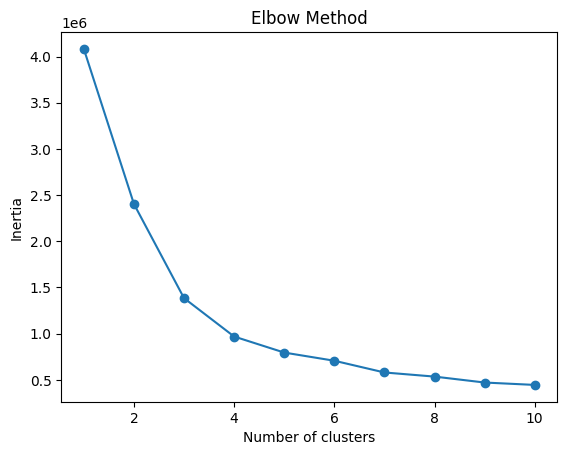

In [4]:
import matplotlib.pyplot as plt

inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [ ]:
# # k=3으로 학습
# kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
# rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# # 각 클러스터별 RFM 평균값 확인
# print(rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean())

            Recency  Frequency     Monetary
Cluster                                    
0        109.120801   5.920380   296.569244
1         40.983301  29.172185  1946.516724
2        518.421460   1.798812    97.547363


In [75]:
# 통계적 신뢰도 (중심극한정리)
# # Silhouette Score(실루엣 계수)
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# 1. 무작위로 10,000개의 인덱스 추출 (130만 건 중 1만 건)
sample_size = 100000
np.random.seed(42) # 결과 재현을 위해 랜덤 시드 고정
indices = np.random.choice(len(rfm_scaled), sample_size, replace=False)

# 2. 추출된 인덱스에 해당하는 데이터만 따로 저장
rfm_scaled_sample = rfm_scaled[indices]

# 3. K=3일 때의 점수 계산
kmeans3 = KMeans(n_clusters=3, init='k-means++', random_state=42)
labels3 = kmeans3.fit_predict(rfm_scaled) # 전체 데이터 학습
labels3_sample = labels3[indices] # 샘플에 해당하는 라벨만 추출
score3 = silhouette_score(rfm_scaled_sample, labels3_sample)

# 4. K=4일 때의 점수 계산
kmeans4 = KMeans(n_clusters=4, init='k-means++', random_state=42)
labels4 = kmeans4.fit_predict(rfm_scaled) # 전체 데이터 학습
labels4_sample = labels4[indices] # 샘플에 해당하는 라벨만 추출
score4 = silhouette_score(rfm_scaled_sample, labels4_sample)

print(f"표본(1만건) 기준 K=3 실루엣 점수: {score3:.4f}")
print(f"표본(1만건) 기준 K=4 실루엣 점수: {score4:.4f}")

표본(1만건) 기준 K=3 실루엣 점수: 0.5022
표본(1만건) 기준 K=4 실루엣 점수: 0.5043


In [5]:
# 1. 최적의 k=4로 모델 확정
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# 2. 각 클러스터별 평균값 계산 (원본 데이터 기준)
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).rename(columns={'Recency': '최근성(일)', 'Frequency': '방문횟수(번)', 'Monetary': '총구매금액($)'})

# 3. 클러스터별 고객 수 확인
cluster_profile['고객수'] = rfm['Cluster'].value_counts()

print(cluster_profile.sort_values('총구매금액($)', ascending=False))

             최근성(일)    방문횟수(번)     총구매금액($)     고객수
Cluster                                            
3         29.652834  42.032065  3189.160889   35303
1         56.792164  18.131518  1019.053345  210709
0        127.564804   4.141481   200.952103  708223
2        536.825626   1.791610    97.952927  406684


In [ ]:
============================================

In [6]:
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. ANOVA 분석 (Monetary: 총 구매금액 기준)군집간에 평균차이가 있는가
f_val, p_val = stats.f_oneway(rfm[rfm['Cluster']==0]['Monetary'],
                              rfm[rfm['Cluster']==1]['Monetary'],
                              rfm[rfm['Cluster']==2]['Monetary'],
                              rfm[rfm['Cluster']==3]['Monetary'])

print(f"ANOVA 결과: F={f_val:.2f}, p-value={p_val:.4f}")

# 2. 사후 검정 (Tukey HSD)
# 어떤 군집끼리 구체적으로 차이가 나는지 확인
tukey = pairwise_tukeyhsd(endog=rfm['Monetary'],     # 데이터
                          groups=rfm['Cluster'],      # 그룹
                          alpha=0.05)                # 유의수준
print(tukey)

ANOVA 결과: F=1367160.88, p-value=0.0000
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj   lower     upper   reject
--------------------------------------------------------
     0      1  818.1013   0.0  816.0621  820.1405   True
     0      2 -102.9992   0.0  -104.616 -101.3824   True
     0      3 2988.2088   0.0 2983.7274 2992.6901   True
     1      2 -921.1004   0.0 -923.3062 -918.8947   True
     1      3 2170.1075   0.0 2165.3816 2174.8334   True
     2      3  3091.208   0.0 3086.6484 3095.7675   True
--------------------------------------------------------


In [7]:
# 군집별 매출 비중 계산 
# 소수의 핵심 고객이 전체 매출을 견인하고 있는가?
#(해당 군집 고객수 ÷ 전체 고객수 합계) × 100
#(해당 군집 매출액 ÷ 전체 매출액 합계) × 100
impact = rfm.groupby('Cluster').agg({
    'customer_id': 'count',
    'Monetary': 'sum'
}).rename(columns={'customer_id': '고객수', 'Monetary': '총매출'})

impact['고객비중(%)'] = (impact['고객수'] / impact['고객수'].sum()) * 100
impact['매출비중(%)'] = (impact['총매출'] / impact['총매출'].sum()) * 100

print(impact.sort_values('매출비중(%)', ascending=False))

            고객수          총매출    고객비중(%)    매출비중(%)
Cluster                                           
1        210709  214723712.0  15.482847  42.146862
0        708223  142318896.0  52.040055  27.934944
3         35303  112586944.0   2.594056  22.099033
2        406684   39835888.0  29.883042   7.819153


In [ ]:
# 구분,일반 RFM (K-means용),Lifetimes 모델 (LTV용)
# 정의,현재(기준일)로부터 마지막 구매가 얼마나 최근인가?,첫 구매일로부터 마지막 구매가 얼마나 나중에 일어났는가?
# 수치 의미,작을수록 최근 고객 (좋음),클수록 오랫동안 우리 서비스를 이용 중 (좋음)
# 계산식,기준일 - 마지막 구매일,   마지막 구매일 - 첫 구매일

In [ ]:
# df['t_dat'] = pd.to_datetime(df['t_dat'])
# snapshot_date = df['t_dat'].max() + pd.Timedelta(days=1)

# rfm = df.groupby('customer_id').agg(
#     Recency=('t_dat', lambda x: (snapshot_date - x.max()).days),# 마지막 구매가 얼마나 최근이냐
#     Frequency=('t_dat', 'nunique'),
#     Monetary=('price', 'sum')
# ).reset_index()
ltv_df = rfm.copy()

# 2. 값 가공 (이미 Frequency가 구매 일수/횟수라면 1을 빼서 '재구매' 횟수로 만듭니다)
ltv_df['frequency_ltv'] = ltv_df['Frequency'] - 1
ltv_df['monetary_avg'] = ltv_df['Monetary'] / ltv_df['Frequency']#재방문횟수
# 원본 데이터 df를 활용해 고객별 첫 구매일 계산
customer_first_purchase = df.groupby('customer_id')['t_dat'].min().reset_index()
customer_first_purchase.columns = ['customer_id', 'first_purchase']

# 기존 rfm 데이터프레임과 병합
ltv_df = pd.merge(rfm, customer_first_purchase, on='customer_id')

# T (Age): 첫 구매일부터 snapshot_date까지의 총 기간(일 단위)
ltv_df['T'] = (snapshot_date - ltv_df['first_purchase']).dt.days

# LTV 모델용 Recency: 첫 구매일부터 마지막 구매일까지의 기간 (lifetimes 모델 기준)
# 주의: 기존 Recency(기준일 - 마지막 구매일)와는 다른 개념입니다.
ltv_df['recency_ltv'] = ltv_df['T'] - ltv_df['Recency']

# Frequency: 재방문 횟수 (전체 방문횟수 - 1)
ltv_df['frequency_ltv'] = ltv_df['Frequency'] - 1

# Monetary: 1회 방문당 평균 구매 금액
ltv_df['monetary_avg'] = ltv_df['Monetary'] / ltv_df['Frequency']

In [9]:
from lifetimes import BetaGeoFitter, GammaGammaFitter

# [단계 1] BG/NBD 모델 학습 앞으로 몇 번 더 올지를 예측
bgf = BetaGeoFitter(penalizer_coef=0.01)
# lifetimes 모델 공식 기준: frequency_ltv, recency_ltv, T 사용
bgf.fit(ltv_df['frequency_ltv'], ltv_df['recency_ltv'], ltv_df['T'])

# [단계 2] Gamma-Gamma 모델 학습 (수익성 예측)한 번 올때 얼마를 쓸지를 예측
returning_customers = ltv_df[ltv_df['frequency_ltv'] > 0]
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(returning_customers['frequency_ltv'], returning_customers['monetary_avg'])

# [단계 3] 향후 365일 예상 LTV(CLV) 계산(향후 365일 동안의 기대 수익을 고객별로 예측)
ltv_df['predicted_clv'] = ggf.customer_lifetime_value(
    bgf,
    ltv_df['frequency_ltv'], ltv_df['recency_ltv'], ltv_df['T'], ltv_df['monetary_avg'],
    time=365, discount_rate=0
)
# [단계 4] Cluster 0의 잠재력 입증
cluster_0 = ltv_df[ltv_df['Cluster'] == 0]
print("--- Cluster 0 예상 가치 요약 ---")
print(cluster_0['predicted_clv'].describe())

--- Cluster 0 예상 가치 요약 ---
count    518182.000000
mean       3990.496901
std        3431.511544
min           0.014107
25%        1772.303255
50%        3167.641164
75%        5189.170060
max      139500.518755
Name: predicted_clv, dtype: float64


In [12]:
# T (Age): 고객이 우리 서비스에서 첫 구매를 한 후 현재까지 경과한 총 일수입니다.

# recency_ltv: 첫 구매일로부터 마지막 구매일 사이의 기간입니다. 이 값이 T와 가까울수록 최근까지도 활발하게 구매했다는 뜻입니다.

# frequency_ltv: 재구매 횟수입니다 (전체 구매 횟수 - 1). 표의 고객들은 14회에서 많게는 65회까지 재구매를 한 헤비 유저들입니다.

# monetary_avg: 1회 방문 시 지출하는 평균 구매 금액입니다.

# predicted_clv: BG/NBD와 Gamma-Gamma 모델이 예측한 향후 12개월간의 예상 가치입니다.
cluster_0

,customer_id,Recency,Frequency,Monetary,Cluster,first_purchase,T,recency_ltv,frequency_ltv,monetary_avg,predicted_clv
0,0,18,10,382.899994,0,2018-12-27,636,618,9,38.290001,5180.733545
2,2,8,7,415.820007,0,2018-09-20,734,726,6,59.402859,4843.753646
4,4,42,6,277.119995,0,2018-10-12,712,670,5,46.186665,3278.582585
6,6,9,3,97.940002,0,2019-06-04,477,468,2,32.646667,1555.471778
8,8,262,1,31.480000,0,2020-01-05,262,0,0,31.480000,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1360906,1362268,161,3,554.729980,0,2019-06-20,461,300,2,184.909988,8146.302644
1360907,1362269,131,6,229.819992,0,2019-06-01,480,349,5,38.303333,3679.070744
1360911,1362273,113,3,229.910004,0,2019-01-23,609,496,2,76.636665,2793.209524
1360917,1362279,93,4,123.430000,0,2020-04-05,171,78,3,30.857500,4058.245685


In [11]:
vvip_customer = cluster_0.sort_values(by='predicted_clv', ascending=False)
vvip_customer

,customer_id,Recency,Frequency,Monetary,Cluster,first_purchase,T,recency_ltv,frequency_ltv,monetary_avg,predicted_clv
1300717,1302027,7,2,1279.520020,0,2020-09-15,8,1,1,639.760010,139500.518755
627782,628428,1,2,877.429993,0,2020-09-20,3,2,1,438.714996,107077.387471
1139978,1141119,3,2,870.489990,0,2020-09-19,4,1,1,435.244995,103601.464151
1164741,1165905,1,3,798.789978,0,2020-09-12,11,10,2,266.263336,96716.028490
784704,785511,9,2,933.989990,0,2020-09-12,11,2,1,466.994995,96457.220869
...,...,...,...,...,...,...,...,...,...,...,...
1360884,1362246,252,1,24.990000,0,2020-01-15,252,0,0,24.990000,NaN
1360897,1362259,144,1,39.970001,0,2020-05-02,144,0,0,39.970001,NaN
1360899,1362261,166,1,26.980000,0,2020-04-10,166,0,0,26.980000,NaN
1360905,1362267,306,1,22.980000,0,2019-11-22,306,0,0,22.980000,NaN


In [46]:
cluster_0.isna().sum()

customer_id            0
Recency                0
Frequency              0
Monetary               0
Cluster                0
first_purchase         0
T                      0
recency_ltv            0
frequency_ltv          0
monetary_avg           0
predicted_clv     190041
dtype: int64

In [14]:
!pip install lifetimes

   ---------------------------------------- 0.0/584.2 kB ? eta -:--:--
   --------------------------------------- 584.2/584.2 kB 13.0 MB/s eta 0:00:00

   ---------------------------------------- 0/2 [autograd]
   ---------------------------------------- 2/2 [lifetimes]



In [ ]:
# BG/NBD & Gamma-Gamma 모델: 고객의 구매 빈도와 평균 결제 금액을 결합하여 
# 향후 일정 기간 내 발생할 예상 매출을 계산합니다.
# Cluster 3 중에서도 LTV가 높게 예측되는 집단이 있다면 타겟팅의 강력한 근거가 됩니다.
#독립성 확인: Gamma-Gamma 모델은 "구매 빈도와 평균 금액 사이에 상관관계가 낮다"는 전제가 필요합니다.
# lifetimes 패키지의 Gamma-Gamma 모델은 **"첫 번째 구매(Initial Purchase)를 
# 제외한 재구매 시의 평균 금액"**을 넣는 것을 권장하거나, 
# 혹은 전체 평균을 넣더라도 frequency가 0인 고객(단발성 고객)은 제외하고 학습시켜야 합니다.

In [ ]:
# Gamma-Gamma 모델의 신뢰도평가
ltv_df[ltv_df['frequency_ltv'] > 0][['frequency_ltv', 'monetary_avg']].corr()

,frequency_ltv,monetary_avg
frequency_ltv,1.000000,-0.004033
monetary_avg,-0.004033,1.000000


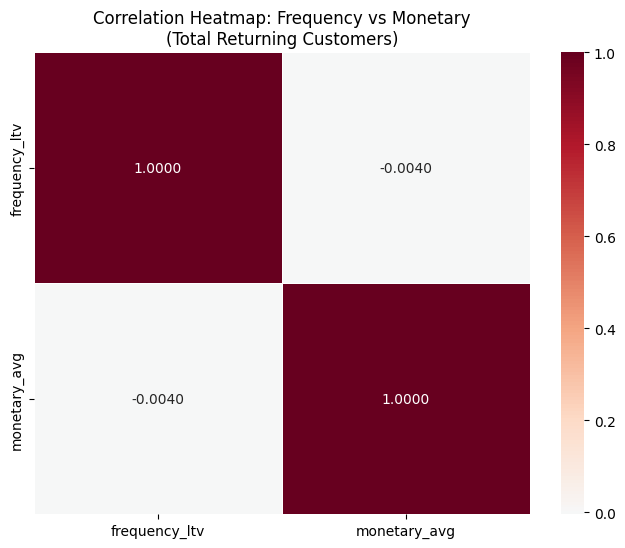

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 재구매 고객(Frequency > 0) 데이터만 추출
returning_customers = ltv_df[ltv_df['frequency_ltv'] > 0]

# 2. 상관계수 계산
corr_matrix = returning_customers[['frequency_ltv', 'monetary_avg']].corr()

# 3. 히트맵 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, 
            annot=True,          # 숫자 표시
            fmt='.4f',           # 소수점 4자리까지 (0.004 확인용)
            cmap='RdBu_r',       # 붉은색(음수) ~ 파란색(양수) 컬러맵
            center=0,            # 0을 기준으로 색상 지정
            linewidths=0.5)      # 셀 사이 구분선

plt.title('Correlation Heatmap: Frequency vs Monetary\n(Total Returning Customers)')
plt.show()

In [10]:
# 모든 군집별 예상 가치(LTV) 평균 비교
comparison = ltv_df.groupby('Cluster')['predicted_clv'].agg(['count', 'mean', 'median', 'max'])
print(comparison.sort_values(by='max', ascending=False))

          count          mean        median            max
Cluster                                                   
3         35301  38964.810497  35744.241967  232532.674901
0        518182   3990.496901   3167.641164  139500.518755
1        210703  12837.165227  11412.813597  134644.748054
2        148760    800.990900    509.563729   13539.174704


In [16]:

impact = ltv_df.groupby('Cluster').agg({
    'customer_id': 'count',
    'Monetary': 'sum',          # 과거 총매출 (기록)
    'predicted_clv': 'sum',     # 예상 총 LTV (미래 기여도)
    'recency_ltv': 'mean'       # (참고용) 군집별 평균 구매 간격
}).rename(columns={'customer_id': '고객수', 'Monetary': '과거총매출', 'predicted_clv': '예상총LTV'})

# 비중 계산
impact['고객비중(%)'] = (impact['고객수'] / impact['고객수'].sum()) * 100
impact['매출비중(%)'] = (impact['과거총매출'] / impact['과거총매출'].sum()) * 100
impact['LTV비중(%)'] = (impact['예상총LTV'] / impact['예상총LTV'].sum()) * 100

# 결과 확인 (타겟인 Cluster 0이 상위에 오도록 설정하거나 군집 순서대로 정렬)
print(impact.sort_index())

            고객수        과거총매출        예상총LTV  recency_ltv    고객비중(%)    매출비중(%)  \
Cluster                                                                         
0        708223  142318896.0  2.067804e+09   280.725548  52.040055  27.934944   
1        210709  214723712.0  2.704829e+09   614.309332  15.482847  42.146862   
2        406684   39835888.0  1.191554e+08    47.352692  29.883042   7.819153   
3         35303  112586944.0  1.375497e+09   678.812877   2.594056  22.099033   

          LTV비중(%)  
Cluster             
0        32.993611  
1        43.157910  
2         1.901228  
3        21.947251  


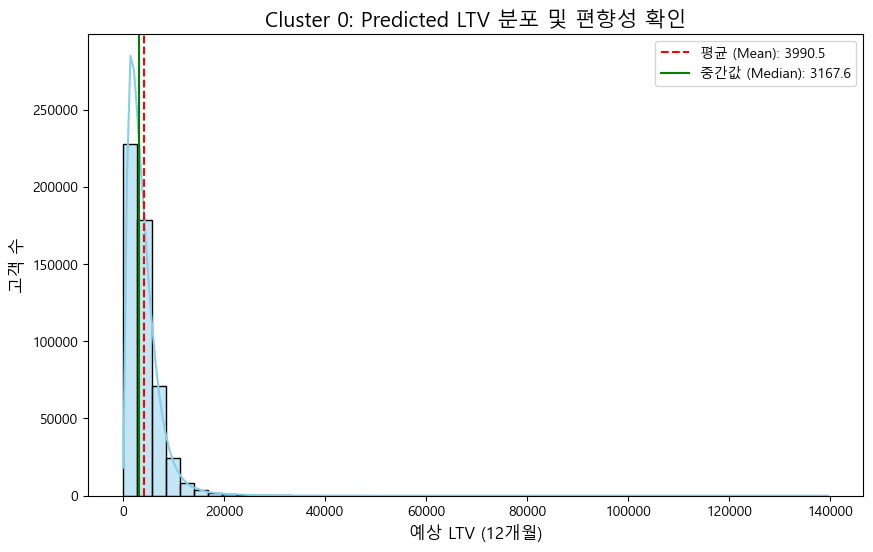

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (환경에 따라 'Malgun Gothic' 등으로 변경 필요)
plt.rcParams['font.family'] = 'Malgun Gothic'

# Cluster 3 데이터 필터링
c0_clv = ltv_df[ltv_df['Cluster'] == 0]['predicted_clv']

plt.figure(figsize=(10, 6))

# 히스토그램과 밀도 곡선
sns.histplot(c0_clv, kde=True, color='skyblue', bins=50)

# 평균(Mean)과 중간값(Median) 표시
plt.axvline(c0_clv.mean(), color='red', linestyle='--', label=f'평균 (Mean): {c0_clv.mean():.1f}')
plt.axvline(c0_clv.median(), color='green', linestyle='-', label=f'중간값 (Median): {c0_clv.median():.1f}')

# 그래프 제목 및 라벨
plt.title('Cluster 0: Predicted LTV 분포 및 편향성 확인', fontsize=15)
plt.xlabel('예상 LTV (12개월)', fontsize=12)
plt.ylabel('고객 수', fontsize=12)
plt.legend()

# 꼬리 부분이 너무 길어 앞부분이 안 보일 경우 x축 범위 제한 (필요시 사용)
# plt.xlim(0, c0_clv.quantile(0.99)) 

plt.show()

In [ ]:
==============================================================

In [ ]:
# # Cluster 300만 복사
# c0_test = rfm[rfm['Cluster'] == 0].copy()

# # 현재 총 매출
# current_revenue = c3_test['Monetary'].sum()

# # [시나리오] 모든 고객이 1회 더 방문하여 자신의 평균 객단가만큼 소비함
# c0_test['Avg_Order_Value'] = c0_test['Monetary'] / c0_test['Frequency']
# c0_test['New_Frequency'] = c0_test['Frequency'] + 1 # 방문 횟수 1 증가
# c0_test['New_Monetary'] = c0_test['Monetary'] + c0_test['Avg_Order_Value'] # 매출 증가

# # 새로운 총 매출
# potential_revenue = c0_test['New_Monetary'].sum()

# # 상승률 계산
# increase_rate = ((potential_revenue - current_revenue) / current_revenue) * 100

# print(f"Cluster 3 고객이 1회 추가 방문 시 매출 상승 기대치: {increase_rate:.2f}%")
# print(f"추가 예상 매출액: ${potential_revenue - current_revenue:,.0f}")

In [6]:
# 1. Cluster 0 고객 아이디만 추출
c0_users = rfm[rfm['Cluster'] == 0]['customer_id']

# 2. 이들이 구매한 상품 정보 결합 (df는 원본 거래 데이터)
c0_data = df[df['customer_id'].isin(c0_users)]

# 3. 이들이 가장 많이 산 '카테고리'와 '상품명' Top 10
print("Cluster 0가 가장 선호하는 카테고리 Top 10")
print(c0_data['product_type_name'].value_counts().head(10))

print("Cluster 0가 가장 많이 산 구체적 상품명 Top 10")
print(c0_data['product_group_name'].value_counts().head(10))

# 4. 이들의 평균 연령대 확인
avg_age = c0_data['age'].mean()
print(f"Cluster 0의 평균 나이: {avg_age:.1f}세")

Cluster 0가 가장 선호하는 카테고리 Top 10
product_type_name
Trousers           1156634
Dress               822469
Sweater             742871
T-shirt             691598
Top                 451578
Bra                 439403
Vest top            437242
Bikini top          392057
Blouse              382220
Swimwear bottom     372018
Name: count, dtype: int64
Cluster 0가 가장 많이 산 구체적 상품명 Top 10
product_group_name
Garment Upper body    3539496
Garment Lower body    1978506
Garment Full body      911250
Swimwear               861531
Underwear              847299
Accessories            466060
Socks & Tights         234506
Shoes                  178211
Nightwear               99167
Unknown                 34994
Name: count, dtype: int64
Cluster 0의 평균 나이: 35.1세


In [7]:
c0_data

,t_dat,customer_id,article_id,price,sales_channel_id,FN,Active,club_member_status,fashion_news_frequency,age,...,product_group_name,graphical_appearance_name,colour_group_name,perceived_colour_value_name,perceived_colour_master_name,department_name,index_name,index_group_name,section_name,garment_group_name
0,2018-09-20,2,663713001,29.990000,2,0,0,ACTIVE,NONE,24,...,Underwear,Solid,Black,Dark,Black,Expressive Lingerie,Lingeries/Tights,Ladieswear,Womens Lingerie,"Under-, Nightwear"
1,2018-09-20,2,541518023,17.990000,2,0,0,ACTIVE,NONE,24,...,Underwear,Solid,Light Pink,Dusty Light,Pink,Casual Lingerie,Lingeries/Tights,Ladieswear,Womens Lingerie,"Under-, Nightwear"
7,2018-09-20,197,688873012,17.990000,1,0,0,ACTIVE,NONE,29,...,Garment Upper body,All over pattern,Light Beige,Dusty Light,Beige,Blouse,Ladieswear,Ladieswear,Womens Tailoring,Blouses
8,2018-09-20,197,501323011,31.490000,1,0,0,ACTIVE,NONE,29,...,Garment Lower body,Solid,Black,Dark,Black,Trouser,Ladieswear,Ladieswear,Womens Tailoring,Trousers
9,2018-09-20,197,598859003,26.990000,2,0,0,ACTIVE,NONE,29,...,Garment Lower body,Solid,Dark Red,Dark,Red,Trouser,Ladieswear,Ladieswear,Womens Tailoring,Trousers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31097411,2020-09-22,1361162,895730002,26.990000,2,0,0,ACTIVE,NONE,46,...,Garment Lower body,Denim,Black,Dark,Black,Denim Other Garments,Divided,Divided,Ladies Denim,Trousers Denim
31097412,2020-09-22,1361162,740519002,26.990000,2,0,0,ACTIVE,NONE,46,...,Garment Lower body,Solid,Black,Dark,Black,Ladies Sport Bottoms,Sport,Sport,Ladies H&M Sport,Jersey Fancy
31097418,2020-09-22,1361247,918522001,24.990000,2,1,1,ACTIVE,Regularly,30,...,Garment Upper body,Solid,Off White,Light,White,Knitwear,Ladieswear,Ladieswear,Womens Everyday Collection,Knitwear
31097419,2020-09-22,1361247,918485001,39.990002,2,1,1,ACTIVE,Regularly,30,...,Garment Upper body,Solid,Light Beige,Dusty Light,Beige,Blouse & Dress,Ladieswear,Ladieswear,Womens Trend,Blouses


In [8]:
# 1. Cluster 0 고객 아이디만 추출
c0_users = rfm[rfm['Cluster'] == 0]['customer_id']

# 2. 이들이 구매한 상품 정보 결합 (df는 원본 거래 데이터)
c0_data = df[df['customer_id'].isin(c0_users)]

# 3. 이들이 가장 많이 산 '카테고리'와 '상품명' Top 10
print("Cluster 0가 가장 선호하는 카테고리 Top 10")
print(c0_data['garment_group_name'].value_counts().head(10))

print("Cluster 0가 가장 많이 산 구체적 상품명 Top 10")
print(c0_data['prod_name'].value_counts().head(10))

# 4. 이들의 평균 연령대 확인
avg_age = c0_data['age'].mean()
print(f"Cluster 0의 평균 나이: {avg_age:.1f}세")

Cluster 0가 가장 선호하는 카테고리 Top 10
garment_group_name
Jersey Fancy         1483053
Jersey Basic         1022000
Under-, Nightwear     962872
Swimwear              851020
Trousers              831867
Blouses               672267
Knitwear              632008
Dresses Ladies        554202
Accessories           482186
Trousers Denim        340989
Name: count, dtype: int64
Cluster 0가 가장 많이 산 구체적 상품명 Top 10
prod_name
Jade HW Skinny Denim TRS       59766
Timeless Midrise Brief         49924
Luna skinny RW                 45871
Tilly (1)                      40131
Simple as That Triangle Top    31982
Cat Tee.                       31024
Tilda tank                     29304
Simple as that Cheeky Tanga    26574
Shake it in Balconette         26211
Skinny Ankle R.W Brooklyn      23244
Name: count, dtype: int64
Cluster 0의 평균 나이: 35.1세


In [7]:
c0_data['product_type_name'].value_counts().head(10)

product_type_name
Trousers           1156634
Dress               822469
Sweater             742871
T-shirt             691598
Top                 451578
Bra                 439403
Vest top            437242
Bikini top          392057
Blouse              382220
Swimwear bottom     372018
Name: count, dtype: int64

In [ ]:
# 지지도 전체거리 중 a와b를 동시에 구매한 비율
# 신뢰도  a를 샀을때 b도 샀을 확률
# 향상도 a를 샀을때 b를 사는것이 그냥 b를 살때보다 얼마나 확률이 높은가

In [ ]:
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules
# apriori 대신 fpgrowth 사용 (속도가 훨씬 빠르고 메모리 사용량이 적음)
# 1. 한 전표(customer_id)당 구매한 상품 리스트를 원-핫 인코딩 형태로 변환
basket = (c0_data.groupby(['customer_id', 'product_type_name'])['product_type_name']
          .count().unstack().reset_index().fillna(0)
          .set_index('customer_id'))

# 2. 1 이상은 1로, 0은 0으로 변환 (구매 여부만 판단)
def encode_units(x):
    if x <= 0: return 0
    if x >= 1: return 1

basket_sets = basket.applymap(encode_units)

frequent_itemsets = fpgrowth(basket_sets, min_support=0.05, use_colnames=True)#전체거래중 5%이상같이 사야함
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

rules.sort_values('lift', ascending=False)

# antecedents  이걸산사람이
# consequents  이것도 사더라
# antecedent support a의 인기(단독으로 구매한 비율)
# consequent support b의 인기(단독으로 구매한 비율)
# support 지지도 a와b를 동시에 구매한비율
# confidence a를 산 사람이 b도 살 확률
# lift 1보다 크면 유의미(연관성이 높다)
# leverage 0이면 독립,양수면 연관성있음
# conviction(확신성) 1이면관계없음,값이 커질수록 a를 샀는데 b를 안살확률이 낮음

c:\Users\dlcks\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1579,"(T-shirt, Bikini top)","(Swimwear bottom, Sweater)",0.097678,0.102664,0.052489,0.537367,5.234234,1.0,0.042461,1.939630,0.896521,0.355008,0.484438,0.524319
1574,"(Swimwear bottom, Sweater)","(T-shirt, Bikini top)",0.102664,0.097678,0.052489,0.511271,5.234234,1.0,0.042461,1.846262,0.901502,0.355008,0.458365,0.524319
1483,"(Trousers, Bikini top)","(Swimwear bottom, Sweater)",0.115524,0.102664,0.061979,0.536502,5.225807,1.0,0.050119,1.936009,0.914261,0.396769,0.483474,0.570105
1478,"(Swimwear bottom, Sweater)","(Trousers, Bikini top)",0.102664,0.115524,0.061979,0.603708,5.225807,1.0,0.050119,2.231878,0.901159,0.396769,0.551947,0.570105
1575,"(Swimwear bottom, T-shirt)","(Sweater, Bikini top)",0.098270,0.102798,0.052489,0.534132,5.195933,1.0,0.042387,1.925872,0.895547,0.353274,0.480755,0.522368
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1432,(Trousers),(Swimwear bottom),0.508485,0.218241,0.116098,0.228320,1.046187,1.0,0.005125,1.013062,0.089820,0.190128,0.012894,0.380146
1455,(Trousers),"(Swimwear bottom, Bikini top)",0.508485,0.191831,0.101005,0.198639,1.035489,1.0,0.003462,1.008496,0.069730,0.168535,0.008424,0.362585
1450,"(Swimwear bottom, Bikini top)",(Trousers),0.191831,0.508485,0.101005,0.526531,1.035489,1.0,0.003462,1.038114,0.042408,0.168535,0.036715,0.362585
1322,(Trousers),(Bikini top),0.508485,0.220851,0.115524,0.227193,1.028715,1.0,0.003225,1.008206,0.056791,0.188208,0.008139,0.375140


In [30]:
# 1. 대상 상품 설정 (개별 문자열로 분리)
item_A1 = 'T-shirt'
item_A2 = 'Bikini top'
item_B1 = 'Vest top'
item_B2 = 'Swimwear bottom'

# 2. 개별 컬럼에 접근하여 조건 생성
# A1도 샀고(1) AND A2도 산(1) 고객
cond_A = (basket_sets[item_A1] == 1) & (basket_sets[item_A2] == 1)

# B1도 안 샀고(0) AND B2도 안 산(0) 고객
cond_B = (basket_sets[item_B1] == 0) & (basket_sets[item_B2] == 0)

# 3. 최종 고객 추출
target_customers = basket_sets[cond_A & cond_B].index

print(f"조건에 맞는 고객 수: {len(target_customers)}명")
print(target_customers.tolist()[:10])

조건에 맞는 고객 수: 4525명
['001ea5b25c75e6490705b22abb670e08007967c631a4c5a9c1473857d2fa41e2', '0020339c4691ddc25e204615ded43854a9fdefbfc14beb561b1e378fda391658', '002745d97a5ab43d3106e405a9872c081f96fad28cfa13ba2f360113fa0751f4', '004b0a6e7c28a52588cb3410d4fc594bd4f1d060d9f1823fbd7582fcc7efc307', '0073e18573581324d654ca9e49aca533e9954cd59172369ef403b9e030d8e9c0', '0084f27bbe226020ec3a25afdd7c9dca10011b7f5b929e4353234faa313b4ffa', '00871d34d93083c1f6d0e1f8934f3177ca878858d4660b7dfff4c1da1fb59952', '009af358aa4305e6b928451c580d8a14ca6e35c2205c1e99536ec43e0bd700aa', '009d8f2fa8187201f56d5c792eab142aeb39af3c7cfffcc40fc02a1dd4adf1ff', '00cc3ef6ba7eb7c651781ba0ce78af2c4e8fba4ce90a2bc962bc27f4ab3c6065']


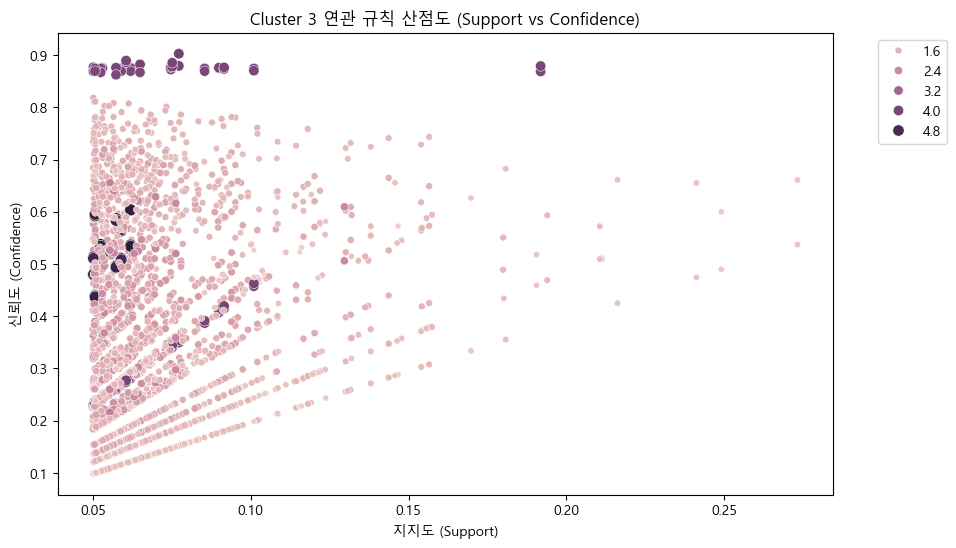

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지 (필요 시)
plt.rcParams['font.family'] = 'Malgun Gothic' 

plt.figure(figsize=(10, 6))
sns.scatterplot(x='support', y='confidence', hue='lift', size='lift', data=rules)
plt.title('Cluster 3 연관 규칙 산점도 (Support vs Confidence)')
plt.xlabel('지지도 (Support)')
plt.ylabel('신뢰도 (Confidence)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

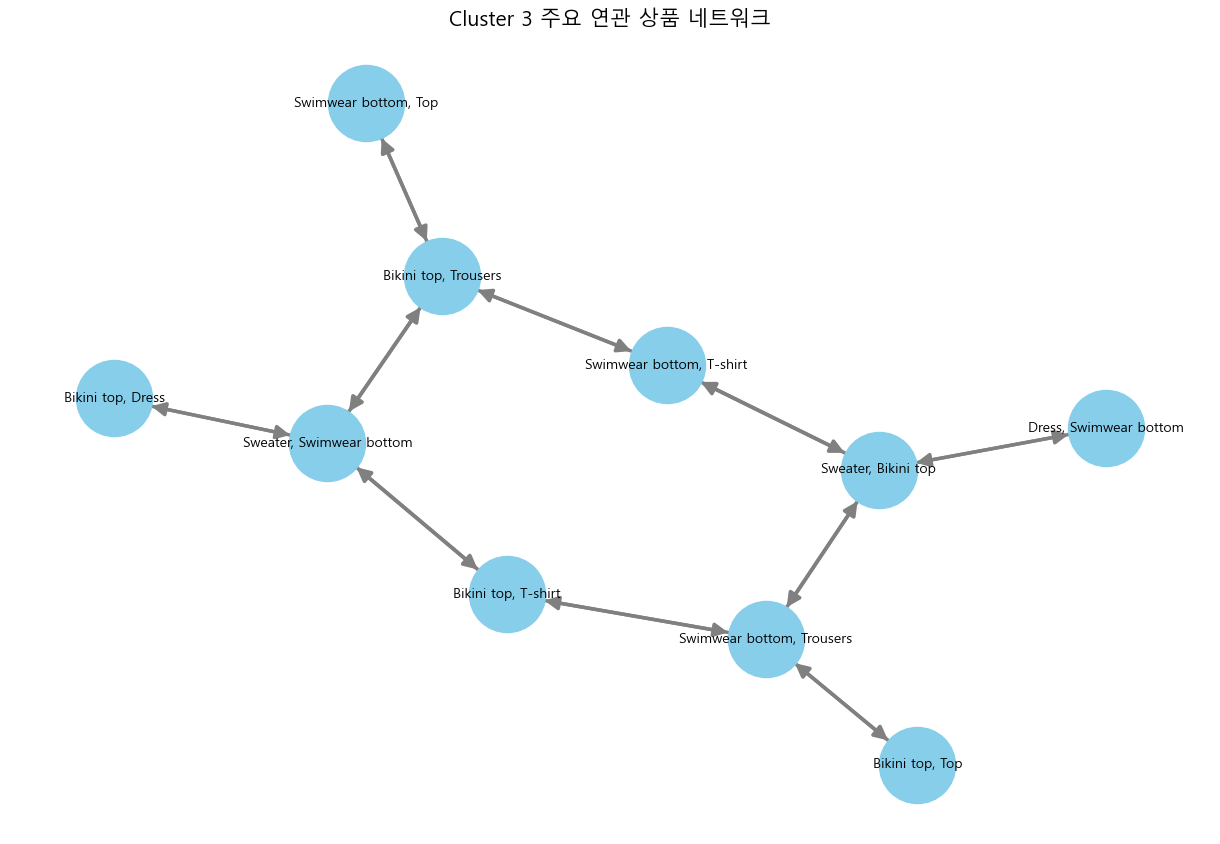

In [23]:
import networkx as nx

# 상위 20개 규칙만 추출 (너무 많으면 그래프가 복잡해짐)
sub_rules = rules.sort_values('lift', ascending=False).head(20)

G = nx.DiGraph()

# 노드와 에지 추가
for i, row in sub_rules.iterrows():
    # frozenset을 문자열로 변환
    ant = ', '.join(list(row['antecedents']))
    con = ', '.join(list(row['consequents']))
    G.add_edge(ant, con, weight=row['lift'])

# 그래프 그리기
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=1)  # 노드 간의 간격 조절
nx.draw(G, pos, with_labels=True, node_size=3000, node_color="skyblue", 
        font_size=10, font_family='Malgun Gothic', edge_color="gray", 
        arrowsize=20, width=[d['weight']/2 for u, v, d in G.edges(data=True)])

plt.title('Cluster 3 주요 연관 상품 네트워크', size=15)
plt.show()

In [24]:
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules

# 1. 한 전표(customer_id)당 구매한 상품 리스트를 원-핫 인코딩 형태로 변환
baskets = (c0_data.groupby(['customer_id', 'colour_group_name'])['colour_group_name']
          .count().unstack().reset_index().fillna(0)
          .set_index('customer_id'))

# 2. 1 이상은 1로, 0은 0으로 변환 (구매 여부만 판단)
def encode_units(x):
    if x <= 0: return 0
    if x >= 1: return 1

basket_sets = baskets.applymap(encode_units)

frequent_itemsets = fpgrowth(basket_sets, min_support=0.05, use_colnames=True)
result = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# 결과 확인 (가장 연관성이 높은 순서대로)
result .sort_values('lift', ascending=False)

c:\Users\dlcks\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1038,"(White, Blue, Black)","(Light Blue, Dark Blue)",0.168748,0.132494,0.055483,0.328790,2.481553,1.0,0.033125,1.292451,0.718225,0.225760,0.226276,0.373773
1051,"(Light Blue, Dark Blue)","(White, Blue, Black)",0.132494,0.168748,0.055483,0.418756,2.481553,1.0,0.033125,1.430127,0.688210,0.225760,0.300761,0.373773
1042,"(Light Blue, Black, Dark Blue)","(White, Blue)",0.126110,0.177688,0.055483,0.439953,2.475983,1.0,0.033074,1.468291,0.682145,0.223435,0.318936,0.376100
1047,"(White, Blue)","(Light Blue, Black, Dark Blue)",0.177688,0.126110,0.055483,0.312246,2.475983,1.0,0.033074,1.270644,0.724932,0.223435,0.212997,0.376100
1023,"(White, Blue)","(Light Blue, Dark Blue)",0.177688,0.132494,0.056914,0.320304,2.417505,1.0,0.033372,1.276315,0.713051,0.224720,0.216494,0.374933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1589,(Black),(Blue),0.831182,0.258434,0.233233,0.280604,1.085786,1.0,0.018427,1.030818,0.468007,0.272347,0.029896,0.591545
1106,(Black),(Beige),0.831182,0.227997,0.205375,0.247087,1.083729,1.0,0.015867,1.025355,0.457654,0.240541,0.024728,0.573932
1107,(Beige),(Black),0.227997,0.831182,0.205375,0.900776,1.083729,1.0,0.015867,1.701385,0.100078,0.240541,0.412244,0.573932
1718,(White),(Black),0.532089,0.831182,0.476792,0.896075,1.078073,1.0,0.034529,1.624420,0.154771,0.537849,0.384396,0.734853


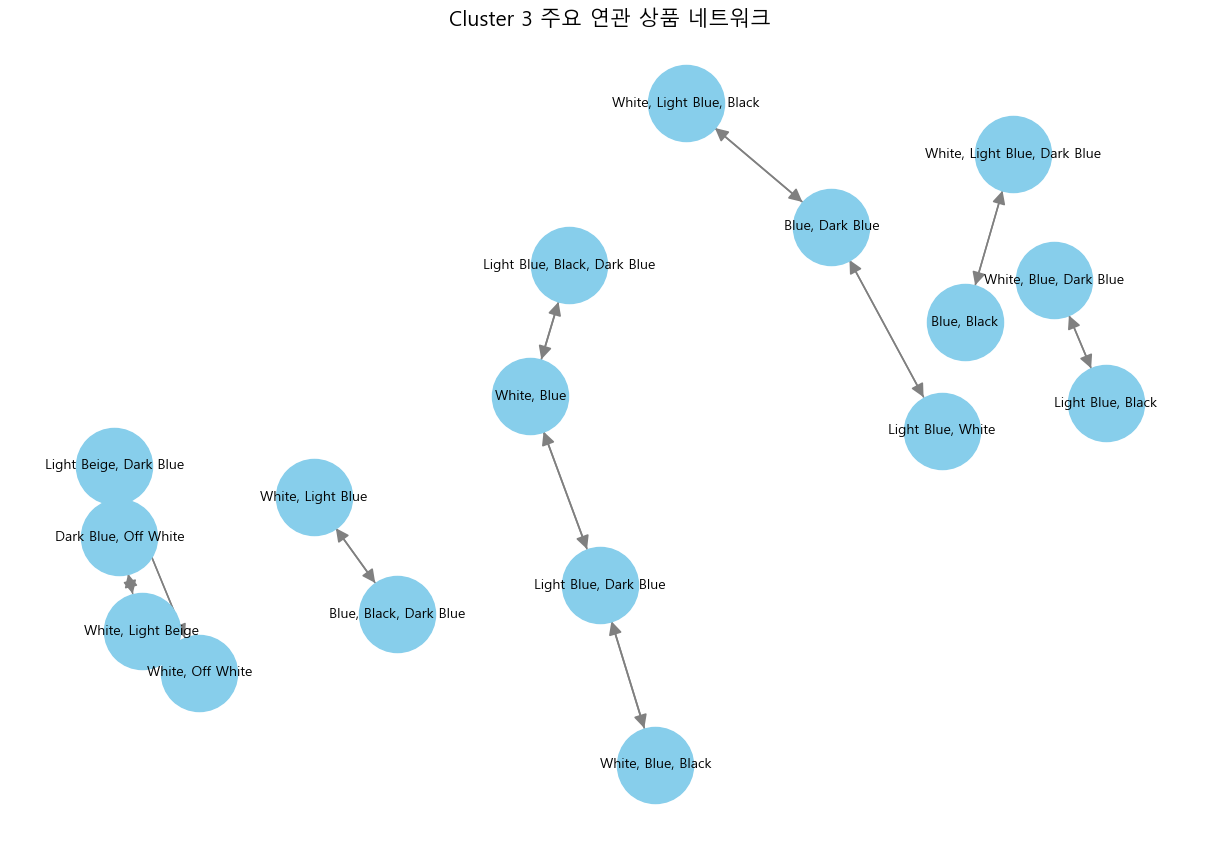

In [25]:
import networkx as nx
import matplotlib.pyplot as plt 

# 한글 깨짐 방지 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False
# 상위 20개 규칙만 추출 (너무 많으면 그래프가 복잡해짐)
sub_rules = result.sort_values('lift', ascending=False).head(20)

G = nx.DiGraph()

# 노드와 에지 추가
for i, row in sub_rules.iterrows():
    # frozenset을 문자열로 변환
    ant = ', '.join(list(row['antecedents']))
    con = ', '.join(list(row['consequents']))
    G.add_edge(ant, con, weight=row['lift'])

# 그래프 그리기
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=1)  # 노드 간의 간격 조절
nx.draw(G, pos, with_labels=True, node_size=3000, node_color="skyblue", 
        font_size=10, font_family='Malgun Gothic', edge_color="gray", 
        arrowsize=20, width=[d['weight']/2 for u, v, d in G.edges(data=True)])

plt.title('Cluster 3 주요 연관 상품 네트워크', size=15)
plt.show()

In [10]:
# 특정옷을 사는데 어떤 색상을 같이 샀는가
import pandas as pd
from mlxtend.frequent_patterns import fpgrowth, association_rules

# 1. '옷 종류' 데이터와 '색상' 데이터를 각각 원-핫 인코딩하여 옆으로 합치기
# 고객별로 어떤 옷 종류를 샀는지 체크
garment_basket = c0_data.groupby(['customer_id', 'product_type_name'])['product_type_name'].count().unstack().fillna(0)

# 고객별로 어떤 색상을 샀는지 체크
color_basket = c0_data.groupby(['customer_id', 'colour_group_name'])['colour_group_name'].count().unstack().fillna(0)

# 두 테이블을 옆으로 합침 (고객 ID 기준)
combined_basket = pd.concat([garment_basket, color_basket], axis=1)

# 2. 샀으면 1, 안 샀으면 0으로 변환
basket_sets = combined_basket.applymap(lambda x: 1 if x > 0 else 0)

# 3. 연관 규칙 분석 실행 (FP-Growth) 3%
frequent_itemsets = fpgrowth(basket_sets, min_support=0.03, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# 4. 결과 필터링
# antecedents에는 옷종류,consequents에는 색상정보
# a사는 사람은b색상을 선호한다
# 수정된 단계 4: 조건(antecedents)에는 오직 '옷 종류'만 있고, 결과(consequents)에는 '색상'만 있는 경우
filtered_rules = rules[
    # 1. 조건절(antecedents)의 모든 아이템이 garment_basket 컬럼(옷 종류)에 속해야 함
    rules['antecedents'].apply(lambda x: all(item in garment_basket.columns for item in x)) & 
    
    # 2. 결과절(consequents)의 모든 아이템이 color_basket 컬럼(색상)에 속해야 함
    rules['consequents'].apply(lambda x: all(item in color_basket.columns for item in x))
]

filtered_rules.sort_values('lift', ascending=False)

c:\Users\dlcks\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
541943,(Earring),"(Black, Gold)",0.051842,0.063858,0.032185,0.620819,9.721808,1.0,0.028874,2.468853,0.946191,0.385372,0.594954,0.562411
541927,(Earring),(Gold),0.051842,0.068830,0.034435,0.664234,9.650348,1.0,0.030867,2.773267,0.945388,0.399312,0.639414,0.582266
443887,"(T-shirt, Trousers, Shorts)","(Dark Blue, Black, White, Blue)",0.095944,0.109514,0.036695,0.382458,3.492333,1.0,0.026187,1.441985,0.789397,0.217433,0.306511,0.358764
448748,"(T-shirt, Trousers, Shorts)","(Dark Blue, Black, Light Blue, White)",0.095944,0.100680,0.033653,0.350758,3.483883,1.0,0.023994,1.385184,0.788628,0.206498,0.278074,0.342508
360485,"(Top, T-shirt, Trousers, Sweater)","(Dark Blue, Black, Grey, White)",0.093942,0.095395,0.031219,0.332321,3.483631,1.0,0.022257,1.354851,0.786863,0.197441,0.261911,0.329791
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360619,(Bikini top),(Black),0.220851,0.831182,0.203682,0.922257,1.109573,1.0,0.020114,2.171481,0.126744,0.240091,0.539485,0.583654
219062,(Blazer),(Black),0.112979,0.831182,0.104145,0.921814,1.109040,1.0,0.010239,2.159180,0.110842,0.123980,0.536861,0.523556
594671,(Pyjama set),(Black),0.051539,0.831182,0.047429,0.920249,1.107157,1.0,0.004590,2.116811,0.102045,0.056781,0.527591,0.488655
11,(Dress),(Black),0.414850,0.831182,0.379861,0.915659,1.101635,1.0,0.035045,2.001607,0.157666,0.438552,0.500401,0.686336


In [ ]:
filtered_rules.sort_values('support', ascending=False)

c:\Users\dlcks\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


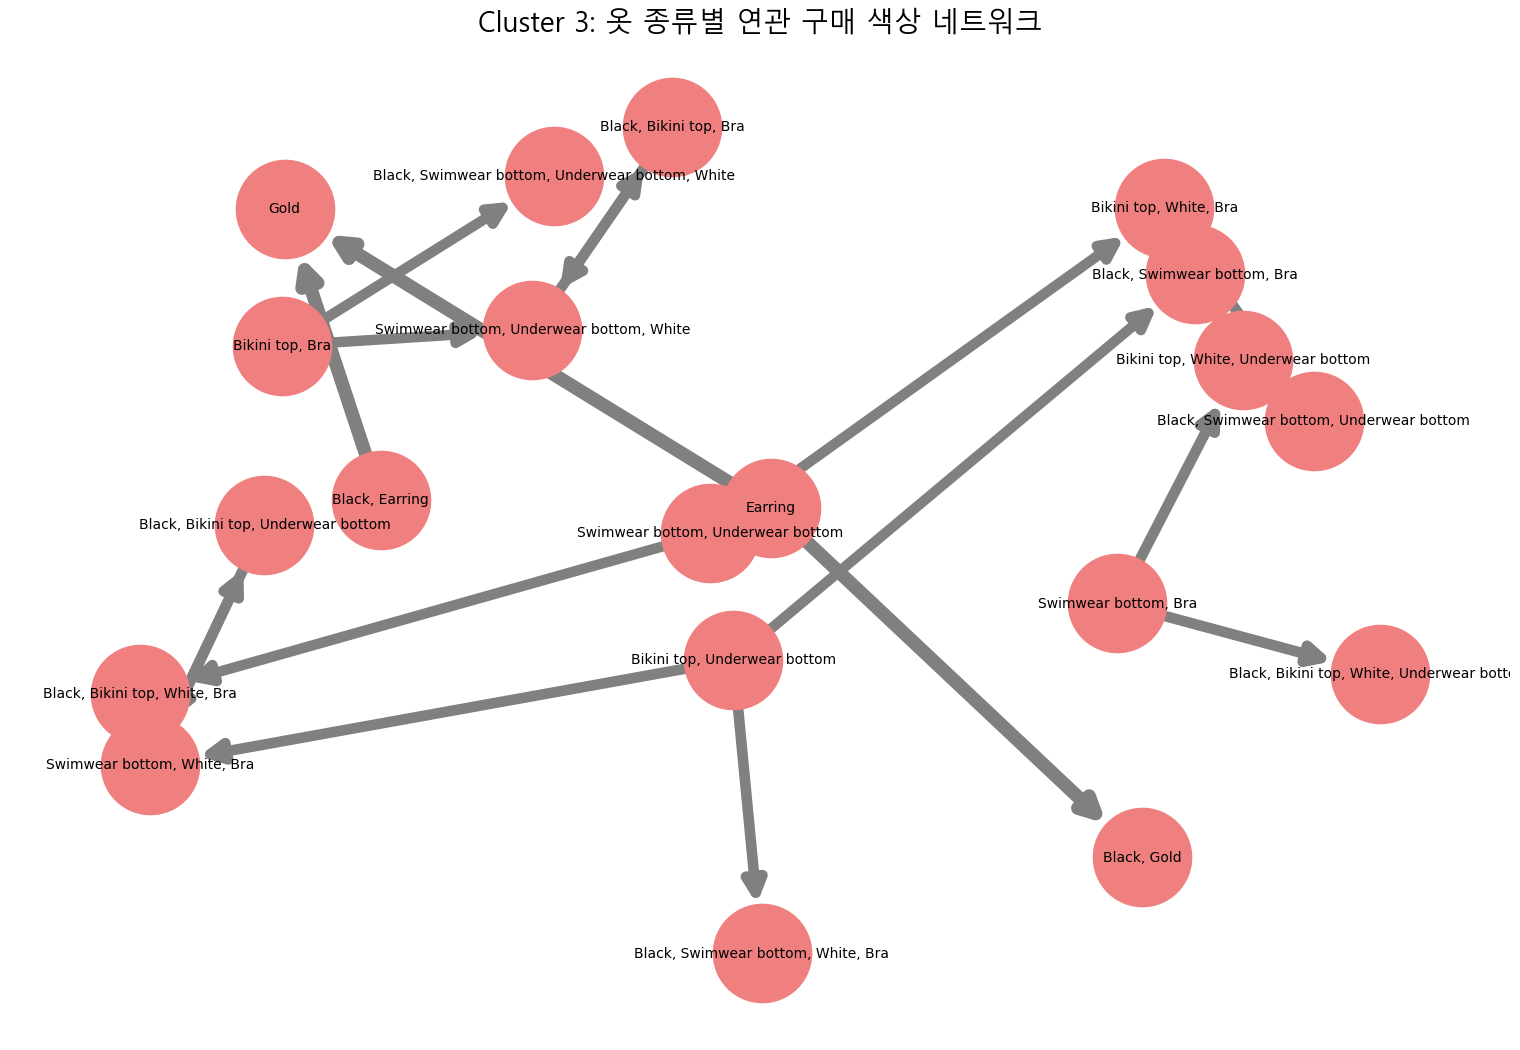

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from mlxtend.frequent_patterns import fpgrowth, association_rules

# 1. 데이터 준비: 옷 종류 열과 색상 열을 각각 만들어서 옆으로 합치기
garment_basket = c0_data.groupby(['customer_id', 'product_type_name'])['product_type_name'].count().unstack().fillna(0)
color_basket = c0_data.groupby(['customer_id', 'colour_group_name'])['colour_group_name'].count().unstack().fillna(0)

# 두 테이블 결합 (고객 한 명이 산 옷 종류와 색상이 한 행에 나열됨)
combined_basket = pd.concat([garment_basket, color_basket], axis=1)
basket_sets = combined_basket.applymap(lambda x: 1 if x > 0 else 0)

# 2. 연관 규칙 분석 (메모리 효율을 위해 fpgrowth 사용)
frequent_itemsets = fpgrowth(basket_sets, min_support=0.03, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# 3. 시각화용 데이터 필터링 (원인: 옷 종류 -> 결과: 색상 인 경우만 추출)
# 이 필터를 거쳐야 '검정색->하얀색' 같은 결과가 빠지고 '상의->검정색' 같은 결과만 남습니다.
viz_rules = rules[
    rules['antecedents'].apply(lambda x: any(item in garment_basket.columns for item in x)) &
    rules['consequents'].apply(lambda x: any(item in color_basket.columns for item in x))
].sort_values('lift', ascending=False).head(20)

# 4. 네트워크 그래프 시각화
G = nx.DiGraph()

for i, row in viz_rules.iterrows():
    ant = ', '.join(list(row['antecedents']))
    con = ', '.join(list(row['consequents']))
    G.add_edge(ant, con, weight=row['lift'])

plt.figure(figsize=(15, 10))
# 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic)
plt.rcParams['font.family'] = 'Malgun Gothic' 

pos = nx.spring_layout(G, k=1.5) # 노드 간격을 조금 더 넓게 설정
nx.draw(G, pos, with_labels=True, 
        node_size=5000, 
        node_color="lightcoral", # 색상 구분을 위해 변경
        font_size=10, 
        edge_color="gray", 
        arrowsize=30, 
        width=[d['weight'] for u, v, d in G.edges(data=True)])

plt.title('Cluster 3: 옷 종류별 연관 구매 색상 네트워크', size=20)
plt.show()

In [ ]:
===========================2/25

In [11]:
# 날짜 형식 변환 (이미 되어 있다면 생략 가능)
c0_data['t_dat'] = pd.to_datetime(c0_data['t_dat'])

# 월(month) 정보 추출
c0_data['month'] = c0_data['t_dat'].dt.month

# 봄/여름 (3월~8월), 가을/겨울 (9월~2월)로 분리 (기준은 비즈니스에 따라 조정 가능)
ss_data = c0_data[c0_data['month'].between(3, 8)]
fw_data = c0_data[(c0_data['month'] >= 9) | (c0_data['month'] <= 2)]

In [ ]:
#계절별 옷종류와색상
def get_seasonal_rules(data, season_name):
    # 장바구니 생성 (기존 코드 로직)
    garment_basket = data.groupby(['customer_id', 'product_type_name'])['product_type_name'].count().unstack().fillna(0)
    color_basket = data.groupby(['customer_id', 'colour_group_name'])['colour_group_name'].count().unstack().fillna(0)
    
    combined = pd.concat([garment_basket, color_basket], axis=1)
    basket_sets = combined.applymap(lambda x: 1 if x > 0 else 0)
    
    # FP-Growth (데이터가 적어질 수 있으므로 min_support를 조금 낮춤)
    frequent = fpgrowth(basket_sets, min_support=0.01, use_colnames=True)
    rules = association_rules(frequent, metric="lift", min_threshold=1)
    
    # 옷 종류 -> 색상 필터링
    filtered = rules[
        rules['antecedents'].apply(lambda x: all(item in garment_basket.columns for item in x)) &
        rules['consequents'].apply(lambda x: all(item in color_basket.columns for item in x))
    ]
    
    print(f"--- {season_name} 분석 완료 ---")
    return filtered.sort_values('lift', ascending=False)

In [13]:
# 봄/여름
ss_rules = get_seasonal_rules(ss_data, "Spring/Summer")

# 가을/겨울
fw_rules = get_seasonal_rules(fw_data, "Fall/Winter")

c:\Users\dlcks\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


--- Spring/Summer 분석 완료 ---


c:\Users\dlcks\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


--- Fall/Winter 분석 완료 ---


In [14]:
#봄/여름
ss_rules.sort_values('lift',ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1352899,"(Earring, Dress)","(Black, Gold)",0.017355,0.043353,0.010677,0.615211,14.190600,1.0,0.009925,2.486157,0.945948,0.213409,0.597773,0.430747
1352942,"(Trousers, Earring)","(Black, Gold)",0.016612,0.043353,0.010215,0.614927,14.184046,1.0,0.009495,2.484323,0.945200,0.205327,0.597476,0.425275
1352841,(Earring),"(Gold, White)",0.034457,0.033793,0.015440,0.448107,13.260265,1.0,0.014276,1.750714,0.957582,0.292376,0.428804,0.452505
1352855,(Earring),"(Black, Gold, White)",0.034457,0.030652,0.013989,0.405989,13.245113,1.0,0.012933,1.631868,0.957492,0.273652,0.387205,0.431185
1352837,(Earring),"(Black, Gold)",0.034457,0.043353,0.019630,0.569710,13.141079,1.0,0.018136,2.223263,0.956873,0.337408,0.550211,0.511254
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
965709,(Dress),"(Unknown, Black)",0.383231,0.028957,0.011532,0.030090,1.039146,1.0,0.000434,1.001169,0.061078,0.028782,0.001167,0.214162
192284,"(Swimwear bottom, Bikini top)",(Greenish Khaki),0.204519,0.179043,0.037883,0.185228,1.034544,1.0,0.001265,1.007591,0.041975,0.109589,0.007534,0.198406
105485,(Bikini top),(Greenish Khaki),0.237013,0.179043,0.043579,0.183866,1.026935,1.0,0.001143,1.005909,0.034377,0.116996,0.005874,0.213631
830324,"(Swimwear bottom, Bikini top)",(Grey),0.204519,0.123391,0.025488,0.124625,1.010002,1.0,0.000252,1.001410,0.012449,0.084280,0.001408,0.165595


In [16]:
#가을/겨울
fw_rules.sort_values('lift',ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
124966,"(Trousers, Earring)","(Black, Gold)",0.018269,0.037380,0.010650,0.582968,15.595829,1.0,0.009967,2.308264,0.953296,0.236676,0.566774,0.433941
124920,"(Sweater, Earring)","(Black, Gold)",0.022402,0.037380,0.012829,0.572675,15.320469,1.0,0.011992,2.252665,0.956148,0.273238,0.556081,0.457945
219784,"(Necklace, Sweater)","(Black, Gold)",0.019328,0.037380,0.010689,0.553039,14.795152,1.0,0.009967,2.153700,0.950787,0.232279,0.535683,0.419500
124989,(Earring),"(Gold, White)",0.036481,0.019119,0.010197,0.279507,14.619433,1.0,0.009499,1.361403,0.966870,0.224580,0.265464,0.406417
124901,(Earring),"(Black, Gold)",0.036481,0.037380,0.019731,0.540852,14.469124,1.0,0.018367,2.096535,0.966132,0.364506,0.523023,0.534347
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43303,(Swimwear bottom),(Grey),0.051456,0.197308,0.010580,0.205606,1.042057,1.0,0.000427,1.010446,0.042549,0.044418,0.010338,0.129613
189224,(Hoodie),(Yellowish Brown),0.131893,0.081502,0.011197,0.084897,1.041646,1.0,0.000448,1.003709,0.046055,0.055378,0.003695,0.111141
202979,(Coat),(Black),0.034182,0.790333,0.028125,0.822803,1.041083,1.0,0.001110,1.183239,0.040859,0.035316,0.154862,0.429195
43059,(Bikini top),(Grey),0.051601,0.197308,0.010480,0.203098,1.029345,1.0,0.000299,1.007266,0.030060,0.043954,0.007213,0.128107


In [ ]:
#(2018-2019)vs(2020)연관상품
# 1. 날짜 형식 확인 및 변환
c0_data['t_dat'] = pd.to_datetime(c0_data['t_dat'])

# 2. 제시하신 기준에 맞춰 데이터 분할
# Pre 기간: 2018-09-20 ~ 2019-12-31
pre_data = c0_data[c0_data['t_dat'].between('2018-09-20', '2019-12-31')]

# Post 기간: 2020-01-01 ~ 2020-09-22
post_data = c0_data[c0_data['t_dat'].between('2020-01-01', '2020-09-22')]

# 3. 기존에 정의한 함수(get_seasonal_rules)를 사용하여 분석 실행
pre_rules = get_seasonal_rules(pre_data, "Pre-Period (2018-2019)")
post_rules = get_seasonal_rules(post_data, "Post-Period (2020)")

c:\Users\dlcks\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


--- Pre-Period (2018-2019) 분석 완료 ---


c:\Users\dlcks\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


--- Post-Period (2020) 분석 완료 ---


In [18]:
#(2018-2019)
pre_rules.sort_values('lift',ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
3451048,"(T-shirt, Earring)","(Gold, White)",0.020261,0.035181,0.010058,0.496438,14.110867,1.0,0.009345,1.915988,0.948347,0.221626,0.478076,0.391168
3450306,"(Trousers, Earring)","(Black, Gold, White)",0.027034,0.033609,0.011861,0.438760,13.054975,1.0,0.010953,1.721886,0.949058,0.243155,0.419242,0.395843
3450132,"(Sweater, Earring)","(Black, Gold, White)",0.028800,0.033609,0.012372,0.429576,12.781707,1.0,0.011404,1.694163,0.949098,0.247255,0.409738,0.398847
3450258,"(Trousers, Earring)","(Gold, White)",0.027034,0.035181,0.012113,0.448084,12.736426,1.0,0.011162,1.748125,0.947088,0.241777,0.427958,0.396199
3450565,"(Earring, Dress)","(Gold, White)",0.022527,0.035181,0.010093,0.448025,12.734770,1.0,0.009300,1.747940,0.942711,0.211962,0.427898,0.367451
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1521715,(Bikini top),(Grey),0.163500,0.219450,0.038400,0.234861,1.070223,1.0,0.002520,1.020141,0.078440,0.111449,0.019743,0.204921
1659682,"(Swimwear bottom, Bikini top)",(Grey),0.141822,0.219450,0.033232,0.234320,1.067759,1.0,0.002109,1.019420,0.073946,0.101304,0.019050,0.192876
4577163,(Bra),(Dark Beige),0.215579,0.069176,0.015483,0.071819,1.038214,1.0,0.000570,1.002848,0.046923,0.057498,0.002840,0.147818
4576867,(Coat),(Black),0.036364,0.830205,0.031125,0.855924,1.030979,1.0,0.000935,1.178509,0.031182,0.037255,0.151470,0.446707


In [19]:
#(2020)
post_rules.sort_values('lift',ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
134415,(Earring),"(Gold, White)",0.027039,0.023141,0.010614,0.392546,16.963510,1.0,0.009988,1.608121,0.967202,0.268267,0.378156,0.425614
134435,(Necklace),"(Black, Gold)",0.024718,0.032742,0.013571,0.549054,16.768985,1.0,0.012762,2.144953,0.964199,0.309221,0.533789,0.481771
134405,(Earring),"(Black, Gold)",0.027039,0.032742,0.014792,0.547048,16.707723,1.0,0.013906,2.135455,0.966275,0.328782,0.531716,0.499407
134393,(Earring),(Gold),0.027039,0.041072,0.018502,0.684258,16.660073,1.0,0.017391,3.037059,0.966099,0.372952,0.670734,0.567367
134426,(Necklace),(Gold),0.024718,0.041072,0.016727,0.676712,16.476363,1.0,0.015711,2.966177,0.963113,0.340925,0.662866,0.541984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134953,(Scarf),(Black),0.014244,0.721160,0.011083,0.778130,1.078998,1.0,0.000811,1.256773,0.074272,0.015302,0.204311,0.396749
37989,(Bikini top),(Beige),0.160511,0.154240,0.026701,0.166349,1.078503,1.0,0.001944,1.014525,0.086707,0.092695,0.014317,0.169730
35658,(Bikini top),(Light Beige),0.160511,0.189280,0.032744,0.203998,1.077757,1.0,0.002362,1.018490,0.085942,0.103278,0.018154,0.188495
129398,(Trousers),(Red),0.358114,0.079938,0.030724,0.085793,1.073245,1.0,0.002097,1.006405,0.106322,0.075427,0.006364,0.235068


In [20]:
#계절별 연관상품
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules
# apriori 대신 fpgrowth 사용 (속도가 훨씬 빠르고 메모리 사용량이 적음)
# 1. 한 전표(customer_id)당 구매한 상품 리스트를 원-핫 인코딩 형태로 변환

# basket 생성 시 ss_data 사용
basket_ss = (ss_data.groupby(['customer_id', 'product_type_name'])['product_type_name']
             .count().unstack().fillna(0))

basket_sets_ss = basket_ss.applymap(lambda x: 1 if x > 0 else 0)
frequent_ss = fpgrowth(basket_sets_ss, min_support=0.01, use_colnames=True)
rules_ss = association_rules(frequent_ss, metric="lift", min_threshold=1)

# basket 생성 시 fw_data 사용
basket_fw = (fw_data.groupby(['customer_id', 'product_type_name'])['product_type_name']
             .count().unstack().fillna(0))
basket_sets_fw = basket_fw.applymap(lambda x: 1 if x > 0 else 0)
frequent_fw = fpgrowth(basket_sets_fw, min_support=0.01, use_colnames=True)
rules_fw = association_rules(frequent_fw, metric="lift", min_threshold=1)

c:\Users\dlcks\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
c:\Users\dlcks\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [26]:
#봄/여름
rules_ss.sort_values('lift',ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
16845,"(Swimwear bottom, Bra)","(Top, Bikini top, Underwear bottom)",0.067324,0.017557,0.010196,0.151451,8.626480,1.0,0.009014,1.157793,0.947894,0.136526,0.136288,0.366109
16832,"(Top, Bikini top, Underwear bottom)","(Swimwear bottom, Bra)",0.017557,0.067324,0.010196,0.580767,8.626480,1.0,0.009014,2.224722,0.899877,0.136526,0.550506,0.366109
17984,"(Underwear bottom, Bikini top, Vest top)","(Swimwear bottom, Bra)",0.022253,0.067324,0.012805,0.575446,8.547444,1.0,0.011307,2.196840,0.903103,0.166800,0.544801,0.382827
18001,"(Swimwear bottom, Bra)","(Underwear bottom, Bikini top, Vest top)",0.067324,0.022253,0.012805,0.190207,8.547444,1.0,0.011307,1.207404,0.946744,0.166800,0.171777,0.382827
12669,"(Top, Bikini top, Shorts)","(T-shirt, Swimwear bottom, Vest top)",0.028943,0.041065,0.010159,0.350990,8.547215,1.0,0.008970,1.477535,0.909322,0.169739,0.323197,0.299187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7623,(Swimwear bottom),(Blouse),0.233121,0.210618,0.049534,0.212480,1.008842,1.0,0.000434,1.002365,0.011429,0.125654,0.002359,0.223831
6586,(Swimwear bottom),"(Trousers, Shirt)",0.233121,0.075603,0.017633,0.075640,1.000487,1.0,0.000009,1.000040,0.000635,0.060577,0.000040,0.154437
6583,"(Trousers, Shirt)",(Swimwear bottom),0.075603,0.233121,0.017633,0.233235,1.000487,1.0,0.000009,1.000148,0.000527,0.060577,0.000148,0.154437
8568,"(Swimwear bottom, Bikini top)",(Blouse),0.204519,0.210618,0.043087,0.210676,1.000280,1.0,0.000012,1.000075,0.000351,0.115811,0.000075,0.207626


In [27]:
#가을/겨울
rules_fw.sort_values('lift',ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1120,"(Swimwear bottom, Sweater)","(Trousers, Bikini top)",0.022934,0.020638,0.010668,0.465144,22.538759,1.0,0.010194,1.831077,0.978063,0.324206,0.453873,0.491025
1125,"(Trousers, Bikini top)","(Swimwear bottom, Sweater)",0.020638,0.022934,0.010668,0.516905,22.538759,1.0,0.010194,2.022513,0.975769,0.324206,0.505566,0.491025
1123,"(Sweater, Bikini top)","(Swimwear bottom, Trousers)",0.023303,0.020823,0.010668,0.457771,21.983692,1.0,0.010182,1.805835,0.977286,0.318827,0.446240,0.485033
1122,"(Swimwear bottom, Trousers)","(Sweater, Bikini top)",0.020823,0.023303,0.010668,0.512296,21.983692,1.0,0.010182,2.002641,0.974810,0.318827,0.500659,0.485033
1098,(Bikini top),"(Swimwear bottom, Bra)",0.051601,0.014426,0.012296,0.238286,16.517695,1.0,0.011551,1.293890,0.990573,0.228839,0.227137,0.545305
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1121,"(Swimwear bottom, Bikini top)","(Trousers, Sweater)",0.042719,0.244128,0.010668,0.249714,1.022881,1.0,0.000239,1.007445,0.023367,0.038626,0.007390,0.146705
2854,(Underwear bottom),(Dress),0.150795,0.240118,0.036969,0.245162,1.021009,1.0,0.000761,1.006683,0.024231,0.104450,0.006639,0.199563
2855,(Dress),(Underwear bottom),0.240118,0.150795,0.036969,0.153963,1.021009,1.0,0.000761,1.003745,0.027079,0.104450,0.003731,0.199563
375,(Bra),(Jacket),0.179978,0.123503,0.022252,0.123637,1.001089,1.0,0.000024,1.000153,0.001327,0.079124,0.000153,0.151905


In [23]:
def get_rules_by_age(df, age_label):
    # 해당 나이대 데이터만 추출
    age_data = df[df['age_group'] == age_label]
    
    # 1. 장바구니 생성 (작성하신 코드 로직 적용)
    basket = (age_data.groupby(['customer_id', 'product_type_name'])['product_type_name']
              .count().unstack().fillna(0))
    
    # 2. 인코딩 (0/1 변환)
    basket_sets = basket.applymap(lambda x: 1 if x > 0 else 0)
    
    # 3. 연관 규칙 실행
    # 나이대별로 쪼개면 데이터가 적어지니 min_support를 0.01~0.03으로 낮추는 걸 추천합니다.
    frequent = fpgrowth(basket_sets, min_support=0.01, use_colnames=True)
    rules = association_rules(frequent, metric="lift", min_threshold=1)
    
    print(f"--- {age_label} 연관 분석 결과 ---")
    return rules.sort_values('lift', ascending=False)

# 실행 예시: 20대 VIP의 연관 상품 보기
rules_20s = get_rules_by_age(c0_data, '20대')
rules_30s = get_rules_by_age(c0_data, '30대')


c:\Users\dlcks\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


--- 20대 연관 분석 결과 ---


c:\Users\dlcks\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


--- 30대 연관 분석 결과 ---


In [28]:
rules_20s.sort_values('lift',ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
299987,"(T-shirt, Swimwear bottom, Bra, Vest top)","(Underwear bottom, Bikini top, Shorts)",0.035269,0.035426,0.010094,0.286196,8.078671,1.0,0.008844,1.351315,0.908250,0.166561,0.259980,0.285560
300022,"(Underwear bottom, Bikini top, Shorts)","(T-shirt, Swimwear bottom, Bra, Vest top)",0.035426,0.035269,0.010094,0.284924,8.078671,1.0,0.008844,1.349132,0.908398,0.166561,0.258783,0.285560
300023,"(Bikini top, Bra, Shorts)","(Underwear bottom, T-shirt, Swimwear bottom, V...",0.045632,0.027630,0.010094,0.221200,8.005742,1.0,0.008833,1.248549,0.916931,0.159792,0.199070,0.293258
299986,"(Underwear bottom, T-shirt, Swimwear bottom, V...","(Bikini top, Bra, Shorts)",0.027630,0.045632,0.010094,0.365316,8.005742,1.0,0.008833,1.503691,0.899956,0.159792,0.334970,0.293258
300034,"(Swimwear bottom, Bra, Shorts)","(Underwear bottom, T-shirt, Bikini top, Vest top)",0.045205,0.027893,0.010094,0.223288,8.005309,1.0,0.008833,1.251568,0.916514,0.160209,0.201002,0.292585
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239005,(Boots),"(Swimwear bottom, Bikini top)",0.055596,0.244076,0.013861,0.249308,1.021435,1.0,0.000291,1.006969,0.022221,0.048495,0.006921,0.153048
238302,(Bikini top),(Boots),0.278894,0.055596,0.015837,0.056784,1.021362,1.0,0.000331,1.001259,0.029005,0.049699,0.001258,0.170818
238303,(Boots),(Bikini top),0.055596,0.278894,0.015837,0.284852,1.021362,1.0,0.000331,1.008331,0.022147,0.049699,0.008262,0.170818
320550,(Bikini top),(Cardigan),0.278894,0.078494,0.022279,0.079884,1.017700,1.0,0.000387,1.001510,0.024119,0.066483,0.001508,0.181857


In [29]:
rules_30s.sort_values('lift',ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
135117,"(Top, Bikini top, Underwear bottom)","(Swimwear bottom, Sweater, Bra, Vest top)",0.034689,0.029062,0.010592,0.305340,10.506353,1.0,0.009584,1.397716,0.937334,0.199248,0.284547,0.334896
135072,"(Swimwear bottom, Sweater, Bra, Vest top)","(Top, Bikini top, Underwear bottom)",0.029062,0.034689,0.010592,0.364452,10.506353,1.0,0.009584,1.518865,0.931903,0.199248,0.341614,0.334896
135127,"(Swimwear bottom, Top, Bra)","(Underwear bottom, Sweater, Bikini top, Vest top)",0.042472,0.023749,0.010592,0.249386,10.500866,1.0,0.009583,1.300603,0.944901,0.190402,0.231126,0.347688
135062,"(Underwear bottom, Sweater, Bikini top, Vest top)","(Swimwear bottom, Top, Bra)",0.023749,0.042472,0.010592,0.445990,10.500866,1.0,0.009583,1.728361,0.926780,0.190402,0.421417,0.347688
135071,"(Underwear bottom, Swimwear bottom, Sweater, V...","(Top, Bikini top, Bra)",0.023801,0.042759,0.010592,0.445013,10.407525,1.0,0.009574,1.724799,0.925955,0.189248,0.420222,0.346362
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220352,(Unknown),(Blouse),0.044802,0.260248,0.012409,0.276980,1.064290,1.0,0.000750,1.023141,0.063240,0.042405,0.022618,0.162331
88272,(Trousers),(Bikini top),0.526645,0.197402,0.110336,0.209508,1.061328,1.0,0.006376,1.015315,0.122073,0.179785,0.015084,0.384225
88273,(Bikini top),(Trousers),0.197402,0.526645,0.110336,0.558943,1.061328,1.0,0.006376,1.073228,0.071996,0.179785,0.068232,0.384225
220349,(Dress),(Unknown),0.448084,0.044802,0.020966,0.046791,1.044388,1.0,0.000891,1.002086,0.077006,0.044428,0.002082,0.257382


In [ ]:
# 연관 분석 결과를 좌표로 환산하는 가장 과학적인 방법은 **'다차원 척도법(Multi-Dimensional Scaling, MDS)'**의 원리를 응용하는 것입니다. 
# Lift(향상도)를 **'인력(Gravity)'**으로 보고, Lift가 높을수록 두 상품 사이의 거리를 가깝게 배치하는 산식을 만들면 됩니다.